---

# University of Liverpool

## COMP534 - Applied AI

---

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


if not os.path.exists("UCMerced_LandUse.zip"):
    print("⬇ Downloading dataset...")
    !wget http://weegee.vision.ucmerced.edu/datasets/UCMerced_LandUse.zip

if not os.path.exists("./UCMerced_LandUse"):
    print(" Unzipping dataset...")
    !unzip UCMerced_LandUse.zip > /dev/null


extract_dir = "./UCMerced_LandUse"
dataset_dir = os.path.join(extract_dir, "Images")


print("Extracted folders:", os.listdir(extract_dir))
print(" Dataset path:", dataset_dir)




⬇ Downloading dataset...
--2025-04-03 11:56:46--  http://weegee.vision.ucmerced.edu/datasets/UCMerced_LandUse.zip
Resolving weegee.vision.ucmerced.edu (weegee.vision.ucmerced.edu)... 169.236.184.65
Connecting to weegee.vision.ucmerced.edu (weegee.vision.ucmerced.edu)|169.236.184.65|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 332468434 (317M) [application/zip]
Saving to: ‘UCMerced_LandUse.zip’

UCMerced_LandUse.zi 100%[===================>] 317.07M  7.12MB/s    in 34s     

2025-04-03 11:57:21 (9.35 MB/s) - ‘UCMerced_LandUse.zip’ saved [332468434/332468434]

 Unzipping dataset...
Extracted folders: ['readme.txt.bak', 'readme.txt', 'Images']
 Dataset path: ./UCMerced_LandUse/Images


# 1. **Data Management**





In [2]:



# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Define transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

full_dataset = datasets.ImageFolder(root=dataset_dir, transform=transform)

# Extract targets (labels) for stratification
targets = np.array(full_dataset.targets)

# 70% train, 15% val, 15% test using StratifiedShuffleSplit
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
for train_idx, temp_idx in sss1.split(np.zeros(len(targets)), targets):
    temp_targets = targets[temp_idx]

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    for val_idx, test_idx in sss2.split(np.zeros(len(temp_targets)), temp_targets):
        val_idx = temp_idx[val_idx]
        test_idx = temp_idx[test_idx]

# Create subset datasets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# 2. **Neural Networks**



In [3]:

# ----- Custom CNN -----
class LandUseCNN(nn.Module):
    def __init__(self, num_classes=21):
        super(LandUseCNN, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=0),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
            )

        self.features = nn.Sequential(
            conv_block(3, 8),
            conv_block(8, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ----- ResNet18 (Feature Extraction) -----
resnet18 = models.resnet18(pretrained=True)
for param in resnet18.parameters():
    param.requires_grad = False
resnet18.fc = nn.Linear(resnet18.fc.in_features, 21)

# ----- ResNet18 (From Scratch) -----
resnet_scratch = models.resnet18(pretrained=False)
resnet_scratch.fc = nn.Linear(resnet_scratch.fc.in_features, 21)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed i

In [4]:
import torch.optim as optim
import torch.nn as nn

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move models to device
model = LandUseCNN().to(device)
resnet18 = resnet18.to(device)
resnet_scratch = resnet_scratch.to(device)
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history



# --- Custom CNN ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(" Training Custom CNN...")
history_custom = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=13)

# --- ResNet18 Feature Extraction ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)
print("Training ResNet18 (Feature Extraction)...")
history_resnet_feat = train_model(resnet18, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# --- ResNet18 From Scratch ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_scratch.parameters(), lr=0.001)
print(" Training ResNet18 (From Scratch)...")
history_resnet_scratch = train_model(resnet_scratch, train_loader, val_loader, criterion, optimizer, num_epochs=12)


 Training Custom CNN...
Epoch [1/13] Train Loss: 2.6117, Train Acc: 0.1952 | Val Loss: 2.1528, Val Acc: 0.3016
Epoch [2/13] Train Loss: 2.0834, Train Acc: 0.3320 | Val Loss: 1.8598, Val Acc: 0.4095
Epoch [3/13] Train Loss: 1.8480, Train Acc: 0.4061 | Val Loss: 1.8055, Val Acc: 0.4159
Epoch [4/13] Train Loss: 1.6572, Train Acc: 0.4449 | Val Loss: 1.5688, Val Acc: 0.4762
Epoch [5/13] Train Loss: 1.5545, Train Acc: 0.4932 | Val Loss: 1.5107, Val Acc: 0.5175
Epoch [6/13] Train Loss: 1.4002, Train Acc: 0.5476 | Val Loss: 1.3388, Val Acc: 0.5841
Epoch [7/13] Train Loss: 1.3449, Train Acc: 0.5605 | Val Loss: 1.3380, Val Acc: 0.6032
Epoch [8/13] Train Loss: 1.2285, Train Acc: 0.6068 | Val Loss: 1.1736, Val Acc: 0.6032
Epoch [9/13] Train Loss: 1.1907, Train Acc: 0.6020 | Val Loss: 1.0699, Val Acc: 0.6286
Epoch [10/13] Train Loss: 1.1727, Train Acc: 0.6272 | Val Loss: 1.0750, Val Acc: 0.6730
Epoch [11/13] Train Loss: 1.0591, Train Acc: 0.6510 | Val Loss: 1.1133, Val Acc: 0.6095
Epoch [12/13] Tra

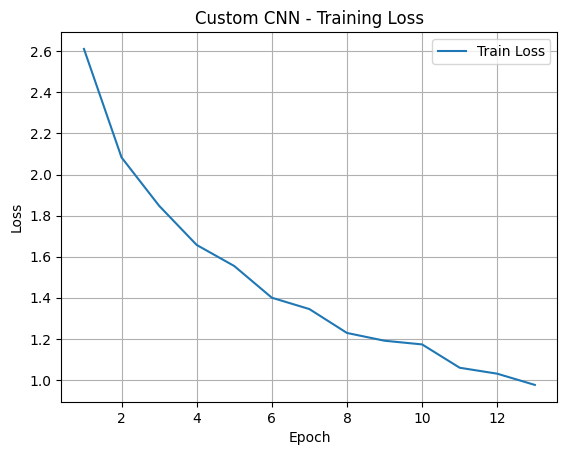

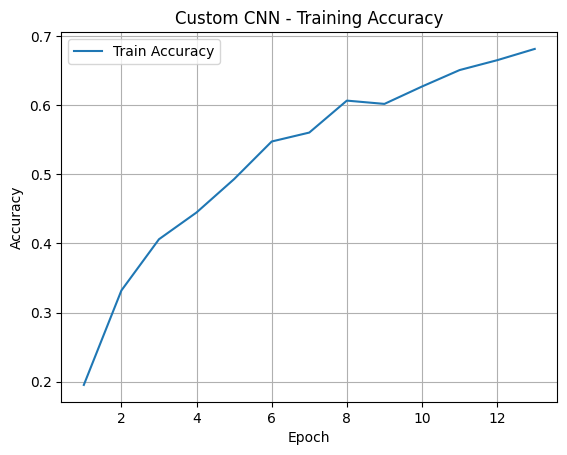

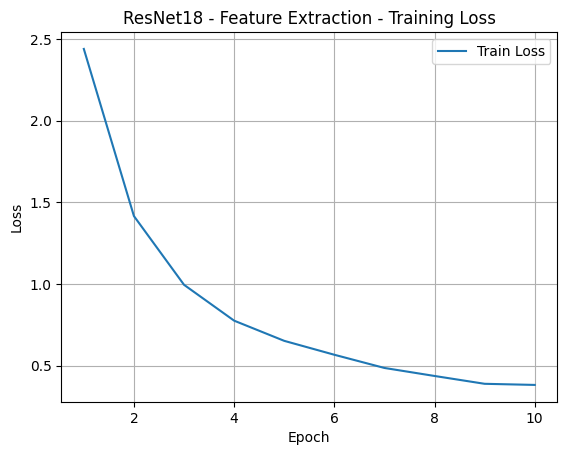

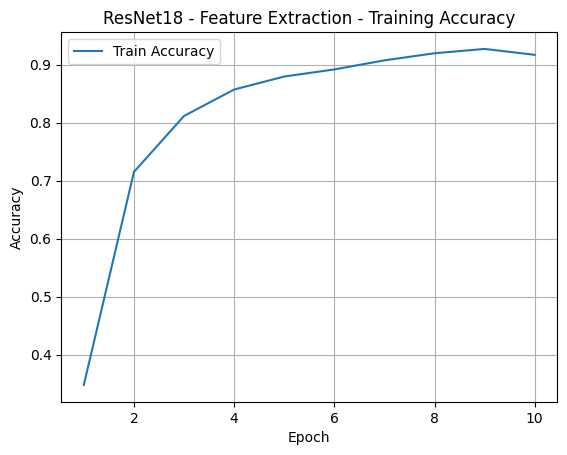

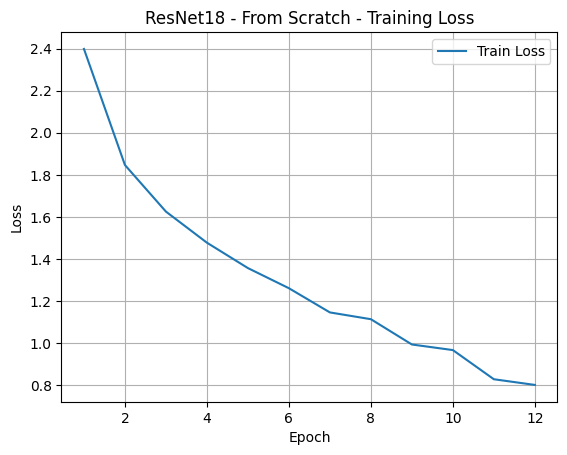

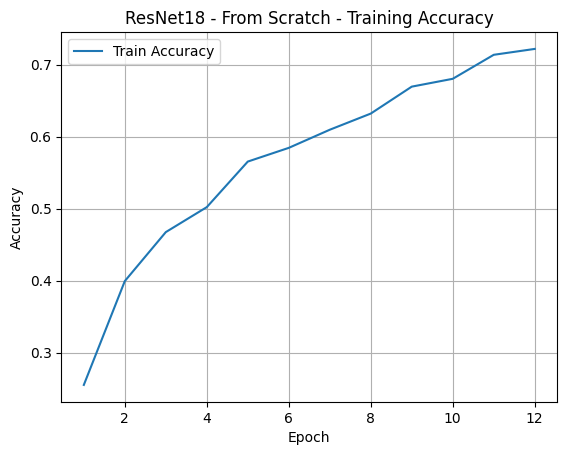

In [5]:


def plot_training_only(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)

    # Plot training loss
    plt.figure()
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.title(f'{model_name} - Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot training accuracy
    plt.figure()
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.title(f'{model_name} - Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot for each model
plot_training_only(history_custom, "Custom CNN")
plot_training_only(history_resnet_feat, "ResNet18 - Feature Extraction")
plot_training_only(history_resnet_scratch, "ResNet18 - From Scratch")



# 3. **Evaluate models**


In [6]:


def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

# Evaluate Custom CNN
acc_custom = evaluate_model(model, test_loader)
print(f" Custom CNN Test Accuracy: {acc_custom:.4f}")

# Evaluate ResNet18 (Feature Extraction)
acc_resnet_feat = evaluate_model(resnet18, test_loader)
print(f" ResNet18 (Feature Extraction) Test Accuracy: {acc_resnet_feat:.4f}")

# Evaluate ResNet18 (From Scratch)
acc_resnet_scratch = evaluate_model(resnet_scratch, test_loader)
print(f" ResNet18 (From Scratch) Test Accuracy: {acc_resnet_scratch:.4f}")

accuracies = {
    "Custom CNN": acc_custom,
    "ResNet18 (Feature Extraction)": acc_resnet_feat,
    "ResNet18 (From Scratch)": acc_resnet_scratch
}

best_model_name = max(accuracies, key=accuracies.get)
print(f"\n Best Model: {best_model_name}")

# Map name to model object
model_map = {
    "Custom CNN": model,
    "ResNet18 (Feature Extraction)": resnet18,
    "ResNet18 (From Scratch)": resnet_scratch
}

best_model = model_map[best_model_name]



 Custom CNN Test Accuracy: 0.6127
 ResNet18 (Feature Extraction) Test Accuracy: 0.8857
 ResNet18 (From Scratch) Test Accuracy: 0.5905

 Best Model: ResNet18 (Feature Extraction)



 Classification Report for ResNet18 (Feature Extraction):
                   precision    recall  f1-score   support

     agricultural       0.94      1.00      0.97        15
         airplane       1.00      0.87      0.93        15
  baseballdiamond       0.93      0.93      0.93        15
            beach       1.00      1.00      1.00        15
        buildings       0.79      1.00      0.88        15
        chaparral       1.00      1.00      1.00        15
 denseresidential       0.62      1.00      0.77        15
           forest       0.79      1.00      0.88        15
          freeway       1.00      0.93      0.97        15
       golfcourse       0.92      0.73      0.81        15
           harbor       1.00      1.00      1.00        15
     intersection       0.72      0.87      0.79        15
mediumresidential       1.00      0.33      0.50        15
   mobilehomepark       0.93      0.87      0.90        15
         overpass       0.94      1.00      0.97       

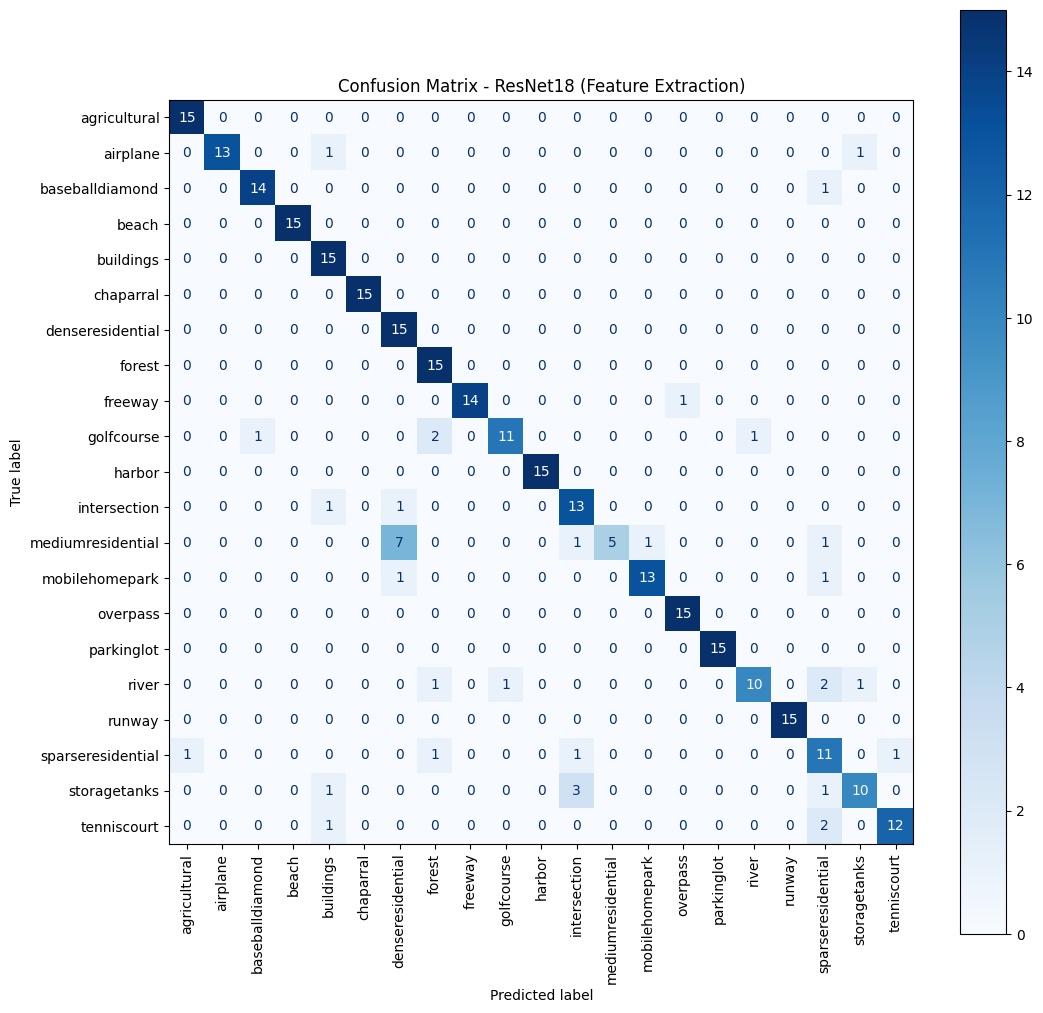

In [7]:


def get_preds_and_labels(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    return np.array(preds), np.array(labels)

# Get preds and labels
y_pred, y_true = get_preds_and_labels(best_model, test_loader)

# Class names from dataset
class_names = test_dataset.dataset.classes

# Classification report
print(f"\n Classification Report for {best_model_name}:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()
